In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.spatial.distance import jensenshannon
import pandas as pd
import pyBigWig as pw
import os 
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 

In [2]:
data = pd.read_csv("configs/model_dir_subsample_atac.csv", sep=",", header=None, names=["fold", "read_depth", "cell_line", "path"])
data = data[data["fold"]=="fold_0"]
data

,fold,read_depth,cell_line,path
0,fold_0,572M,GM12878,/mnt/lab_data2/anusri/chrombpnet/results/chrom...
5,fold_0,250M,GM12878,/oak/stanford/groups/akundaje/projects/chromat...
10,fold_0,100M,GM12878,/oak/stanford/groups/akundaje/projects/chromat...
15,fold_0,50M,GM12878,/oak/stanford/groups/akundaje/projects/chromat...
20,fold_0,25M,GM12878,/oak/stanford/groups/akundaje/projects/chromat...
25,fold_0,5M,GM12878,/oak/stanford/groups/akundaje/projects/chromat...
30,fold_0,15M,GM12878,/oak/stanford/groups/akundaje/projects/chrombp...
35,fold_0,10M,GM12878,/oak/stanford/groups/akundaje/projects/chrombp...
40,fold_0,2M,GM12878,/oak/stanford/groups/akundaje/projects/chrombp...


In [3]:
NARROWPEAK_SCHEMA = ["chr", "start", "end", "1", "2", "3", "4", "5", "6", "summit"]

peaks_df=pd.read_csv("/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/ATAC_PE/GM12878/nautilus_runs/GM12878_03.01.2022_bias_128_4_1234_0.4_fold_0/chrombpnet_model/filtered.peaks.bed", sep="\t", names=NARROWPEAK_SCHEMA)
peaks_df = peaks_df
peaks_df

,chr,start,end,1,2,3,4,5,6,summit
0,chr10,100006179,100007627,Peak_129135,970,.,2.87048,97.04913,95.00385,535
1,chr10,100006179,100007627,Peak_173791,508,.,2.28123,50.81154,48.91285,791
2,chr10,100006179,100007627,Peak_176997,486,.,2.25177,48.66633,46.77644,1352
3,chr10,100006179,100007627,Peak_275211,160,.,1.65440,16.01422,14.33124,1178
4,chr10,100006179,100007627,Peak_74001,1000,.,4.38566,257.53198,255.19798,285
...,...,...,...,...,...,...,...,...,...,...
275537,chr6,9986231,9986949,Peak_98888,1000,.,7.51163,161.72119,159.53831,426
275538,chr6,99868121,99868883,Peak_179643,470,.,4.38829,47.07563,45.19226,363
275539,chr6,99868121,99868883,Peak_72515,1000,.,11.73258,265.15918,262.81454,125
275540,chr6,9989550,9989841,Peak_219907,284,.,3.22789,28.42596,26.64051,178


## Utils

In [4]:
def get_cts(peaks_df, bw, width):
    """
    Fetches values from a bigwig bw, given a df with minimally
    chr, start and summit columns. Summit is relative to start.
    Retrieves values of specified width centered at summit.
    "cts" = per base counts across a region
    """
    vals = []
    for i, r in peaks_df.iterrows():
        vals.append(np.nan_to_num(bw.values(r['chr'], 
                                            r['start'] + r['summit'] - width//2,
                                            r['start'] + r['summit'] + width//2)))
        
    return np.array(vals)

In [5]:
def jsd_pred(profile1_preds, profile2_preds):
    def do_min_max(v):
        return (v - v.min()) / (v.max() - v.min())
  
    assert(profile1_preds.shape==profile2_preds.shape)
    jsd_vals=[]
    for key in range(profile1_preds.shape[0]):
        #jsd_val = jensenshannon(np.abs(profile1_preds[key]), np.abs(profile2_preds[key])) # taking abs on deepshaps
        jsd_val = jensenshannon(do_min_max(profile1_preds[key]), do_min_max(profile2_preds[key]), base=2) # taking abs on deepshaps

        if np.isnan(jsd_val):
            #print(np.sum(profile1_preds[key]),np.sum(profile2_preds[key]))
            pass
        else:
            jsd_vals.append(jsd_val)
    
    return [np.mean(jsd_vals), np.std(jsd_vals)], jsd_vals

In [6]:

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 

def read_and_plot(in_title, peaks_df, in_500M, in_250M, in_100M, in_50M, in_25M, in_15M, in_10M, in_5M, in_2M):
    d_in_500M  = get_cts(peaks_df, in_500M, width=1000)
    d_in_250M  = get_cts(peaks_df, in_250M, width=1000)
    d_in_100M  = get_cts(peaks_df, in_100M, width=1000)
    d_in_50M  = get_cts(peaks_df, in_50M, width=1000)
    d_in_25M  = get_cts(peaks_df, in_25M, width=1000)
    d_in_5M  = get_cts(peaks_df, in_5M, width=1000)
    
    d_in_15M  = get_cts(peaks_df, in_15M, width=1000)
    d_in_10M  = get_cts(peaks_df, in_10M, width=1000)
    d_in_2M  = get_cts(peaks_df, in_2M, width=1000)

    stats_500Mv250M, vals_500Mv250M = jsd_pred(d_in_500M, d_in_250M)
    print("500M vs 250M JSD", stats_500Mv250M)
    stats_500Mv100M, vals_500Mv100M = jsd_pred(d_in_500M, d_in_100M)
    print("500M vs 100M JSD", stats_500Mv100M)
    stats_500Mv50M, vals_500Mv50M = jsd_pred(d_in_500M, d_in_50M)
    print("500M vs 50M JSD", stats_500Mv50M)
    stats_500Mv25M, vals_500Mv25M = jsd_pred(d_in_500M, d_in_25M)
    print("500M vs 25M JSD", stats_500Mv25M)
    stats_500Mv15M, vals_500Mv15M = jsd_pred(d_in_500M, d_in_15M)
    print("500M vs 15M JSD", stats_500Mv15M)
    stats_500Mv10M, vals_500Mv10M = jsd_pred(d_in_500M, d_in_10M)
    print("500M vs 10M JSD", stats_500Mv10M)
    stats_500Mv5M, vals_500Mv5M = jsd_pred(d_in_500M, d_in_5M)
    print("500M vs 5M JSD", stats_500Mv5M)
    stats_500Mv2M, vals_500Mv2M = jsd_pred(d_in_500M, d_in_2M)
    print("500M vs 2M JSD", stats_500Mv2M)
    
    plt.figure(figsize=(15, 10))
    title=in_title
    title1=title
    ecdf = ECDF(vals_500Mv250M)
    plt.plot(ecdf.x, ecdf.y,label="500M " + title + " vs 250M " +title1)
    
    ecdf = ECDF(vals_500Mv100M)
    plt.plot(ecdf.x, ecdf.y,label="500M " + title + " vs 100M " +title1)
    
    ecdf = ECDF(vals_500Mv50M)
    plt.plot(ecdf.x, ecdf.y,label="500M " + title + " vs 50M " +title1)
    
    ecdf = ECDF(vals_500Mv25M)
    plt.plot(ecdf.x, ecdf.y,label="500M " + title + " vs 25M " +title1)
    
    ecdf = ECDF(vals_500Mv15M)
    plt.plot(ecdf.x, ecdf.y,label="500M " + title + " vs 15M " +title1)
    
    ecdf = ECDF(vals_500Mv10M)
    plt.plot(ecdf.x, ecdf.y,label="500M " + title + " vs 10M " +title1)
    
    ecdf = ECDF(vals_500Mv5M)
    plt.plot(ecdf.x, ecdf.y,label="500M " + title + " vs 5M " +title1)
    
    ecdf = ECDF(vals_500Mv2M)
    plt.plot(ecdf.x, ecdf.y,label="500M " + title + " vs 2M " +title1)
    plt.legend(fontsize=12)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel("JSD values", fontsize=18)
    plt.ylabel("ECDF", fontsize=18)
    plt.savefig("figures/"+title.replace(" ","_")+"_new.pdf", dpi=300, transparent=True)
    plt.show()
    

## Counts deepshap

In [9]:
read_depth_query="572M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"interpret/merged.GM12878.counts.bw")
#path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878.counts.bigwig")
in_500M = pw.open(path)

read_depth_query="250M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".counts.bigwig")
in_250M = pw.open(path)

read_depth_query="100M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".counts.bigwig")

in_100M = pw.open(path)

read_depth_query="50M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".counts.bigwig")

in_50M = pw.open(path)

read_depth_query="25M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".counts.bigwig")
in_25M = pw.open(path)

read_depth_query="15M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"interpret/full_GM12878_"+read_depth_query.lower()+".counts.bigwig")
print(path)
in_15M = pw.open(path)

read_depth_query="10M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"interpret/GM12878_"+read_depth_query.lower()+".counts.bigwig")
in_10M = pw.open(path)


read_depth_query="5M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".counts.bigwig")
in_5M = pw.open(path)

read_depth_query="2M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"interpret/GM12878_"+read_depth_query.lower()+".counts.bigwig")
in_2M = pw.open(path)

/oak/stanford/groups/akundaje/projects/chrombpnet/model_inputs/ENCODE_ATAC_downloads/GM12878/GM12878_subsampled/GM12878_bams/subsampled_15m/fold_0/GM12878_15m/interpret/full_GM12878_15m.counts.bigwig


RuntimeError: Received an error during file opening!

In [ ]:
read_and_plot("counts importance", peaks_df, in_500M, in_250M, in_100M, in_50M, in_25M, in_15M, in_10M, in_5M, in_2M)

## profile deephsap

In [23]:
import pyBigWig as pw
read_depth_query="572M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"interpret/merged.GM12878.profile.bw")
#path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878.profile.bigwig")
in_500M = pw.open(path)

read_depth_query="250M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".profile.bigwig")
in_250M = pw.open(path)

read_depth_query="100M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".profile.bigwig")

in_100M = pw.open(path)

read_depth_query="50M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".profile.bigwig")

in_50M = pw.open(path)

read_depth_query="25M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".profile.bigwig")
in_25M = pw.open(path)

read_depth_query="15M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"interpret/full_GM12878_"+read_depth_query.lower()+".profile.bigwig")
print(path)
#in_15M = pw.open("/oak/stanford/groups/akundaje/projects/chrombpnet/model_inputs/ENCODE_ATAC_downloads/GM12878/GM12878_subsampled/GM12878_bams/subsampled_15m/fold_0/GM12878_15m/interpret/full_GM12878_15m.profile.bigwig")
in_15M = pw.open(path)

read_depth_query="10M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"interpret/full_GM12878_"+read_depth_query.lower()+".profile.bigwig")
print(path)
in_10M = pw.open(path)
read_depth_query="5M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"chrombpnet_model/interpret/full_GM12878_"+read_depth_query+".profile.bigwig")
in_5M = pw.open(path)

read_depth_query="2M"
path = os.path.join(data[data["read_depth"] == read_depth_query]["path"].values[0],"interpret/full_GM12878_"+read_depth_query.lower()+".profile.bigwig")
#print(path)
in_2M = pw.open(path)


/oak/stanford/groups/akundaje/projects/chrombpnet/model_inputs/ENCODE_ATAC_downloads/GM12878/GM12878_subsampled/GM12878_bams/subsampled_15m/fold_0/GM12878_15m/interpret/full_GM12878_15m.profile.bigwig
/oak/stanford/groups/akundaje/projects/chrombpnet/model_inputs/ENCODE_ATAC_downloads/GM12878/GM12878_subsampled/GM12878_bams/subsampled_10m/fold_0/GM12878_10m/interpret/full_GM12878_10m.profile.bigwig
/oak/stanford/groups/akundaje/projects/chrombpnet/model_inputs/ENCODE_ATAC_downloads/GM12878/GM12878_subsampled/GM12878_bams/subsampled_2m/fold_0/GM12878_2m/interpret/full_GM12878_2m.profile.bigwig


500M vs 250M JSD [0.08009011793392191, 0.025018324555552533]
500M vs 100M JSD [0.08186903079265682, 0.025501998997006815]
500M vs 50M JSD [0.08283557792609454, 0.025299670741246495]
500M vs 25M JSD [0.08274845981707457, 0.025394673586406184]
500M vs 15M JSD [0.0858147116859094, 0.0261452797103292]
500M vs 10M JSD [0.08574688760364839, 0.02563473783570235]
500M vs 5M JSD [0.09647491207183231, 0.027057283526518764]
500M vs 2M JSD [0.09851263368897752, 0.02719034563332294]


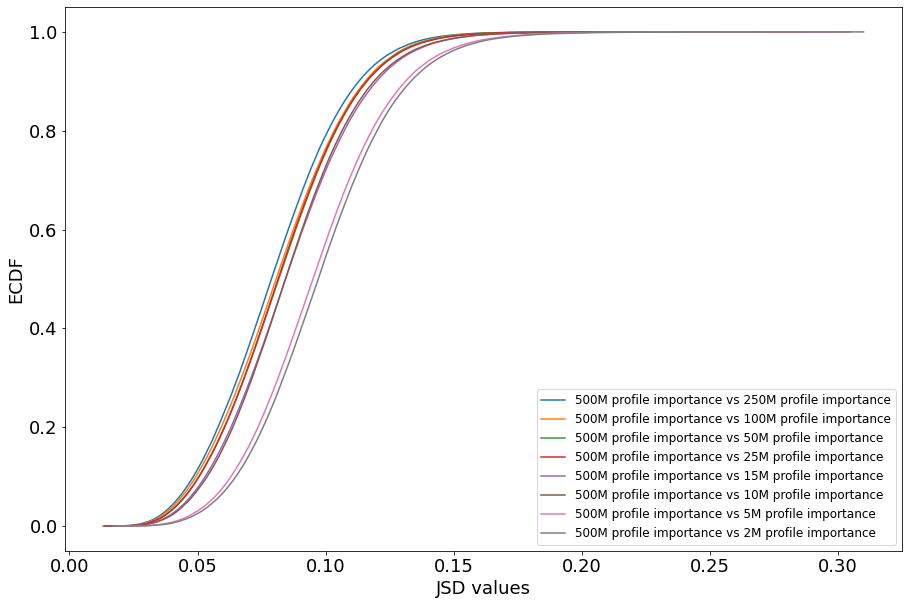

In [24]:
read_and_plot("profile importance", peaks_df, in_500M, in_250M, in_100M, in_50M, in_25M, in_15M, in_10M, in_5M, in_2M)